# Importing Header, SoilPrep, and PlotFunctions

In [1]:
%run Header.ipynb
%run SoilPrep.ipynb
%run LoadDataMetaData.ipynb
%run PlotFunctions.ipynb

## Loading  Mtree 

In [2]:
with open ('HMtree.pickle', 'rb') as file:
    HMtree = pd.read_pickle(file) 

In [3]:
# with open ('Feature.pickle', 'rb') as file:
#     feature_scores = pickle.load(file)
 

In [4]:
# with open ('Models.pickle', 'rb') as file:
#     model_details = pickle.load(file)
 

 #  Best Models for TOC.

In [5]:
feature_scores = {}

model_details ={}

In [13]:
HMtree['TOC']['ridge']['none']['fod_log'][80]

{'bp': {'alpha': 1e-05},
 'X_test':           413       439       465       491       518       544       570  \
 691 -0.158527 -0.106411 -0.089217 -0.140964 -0.123945 -0.093866 -0.057502   
 662 -0.188354 -0.130343 -0.100485 -0.166943 -0.153046 -0.120349 -0.072884   
 63  -0.183735 -0.124459 -0.083243 -0.135527 -0.126000 -0.077708 -0.035068   
 531 -0.152848 -0.125157 -0.100034 -0.126692 -0.112265 -0.090988 -0.066529   
 66  -0.180606 -0.131493 -0.092614 -0.141164 -0.139719 -0.110312 -0.067955   
 ..        ...       ...       ...       ...       ...       ...       ...   
 517 -0.131945 -0.101897 -0.071783 -0.096543 -0.096742 -0.078996 -0.052520   
 587 -0.170655 -0.107658 -0.076729 -0.113672 -0.097809 -0.068940 -0.042910   
 434 -0.128243 -0.080511 -0.056764 -0.099946 -0.086909 -0.057635 -0.032518   
 739 -0.131982 -0.107861 -0.077364 -0.098995 -0.096255 -0.085497 -0.063756   
 511 -0.153154 -0.107718 -0.078326 -0.120096 -0.109627 -0.079055 -0.048082   
 
           596       623   

##  TOC 

### Cubist

TOC -> [ r2 - **0.49**, Spec - fod_log, n_bands - 40]   <br/><br/>
***Description***:To obtain the best model for TOC using cubist method we trained the model on the
 first order derivative of the logarithmic transformed spectra  which is resampled to 40 bands.


In [6]:
fod_log[40] = fod_log[40].copy()
T[0] = T[0].copy()

In [8]:
TOC_model_cubist = Cubist(n_committees = 20, n_rules = 10) 
TOC_model_cubist.fit(fod_log[40],  T[0])

C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())


Cubist(n_committees=20, n_rules=10)

In [9]:
feature_scores['TOC'] = permutation_importance(TOC_model_cubist, fod_log[40], T[0], n_repeats=10, random_state=0)

C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_string.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  x = x.applymap(lambda a: a.lstrip())
C:\Users\abhis\AppData\Local\Programs\Python\Python311\Lib\site-packages\cubist\_make_data_strin

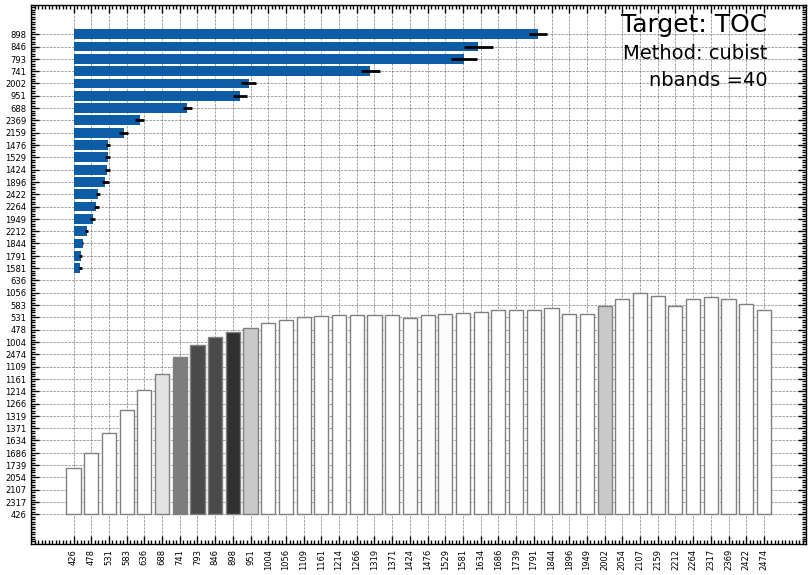

In [11]:
model_details['TOC'] = {'method': 'cubist', 'spec': sampled_spec[40], 'spec_proc': 'fod_log', 'n_bands': 40}
show_important_features_for ('TOC', model_details, feature_scores, 5, 40, 2)

### Kernel Ridge Regression

 TOC -> [ r2 - **0.45**, Spec - fod_log, n_bands -80]   <br/><br/>
***Description***:To obtain the best model for TOC using kernel ridge regression method we trained the model on the first order derivative of the logarithmic transformed spectra which is resampled to 80 bands.


In [12]:
fod_log[80] = fod_log[80].copy()
T[0] = T[0].copy()

In [14]:
TOC_model_kernelridge = KernelRidge(alpha = 0.00001) 
TOC_model_kernelridge.fit(fod_log[80],  T[0])

KernelRidge(alpha=1e-05)

In [15]:
feature_scores['TOC'] = permutation_importance(TOC_model_kernelridge, fod_log[80], T[0], n_repeats=20, random_state=0)

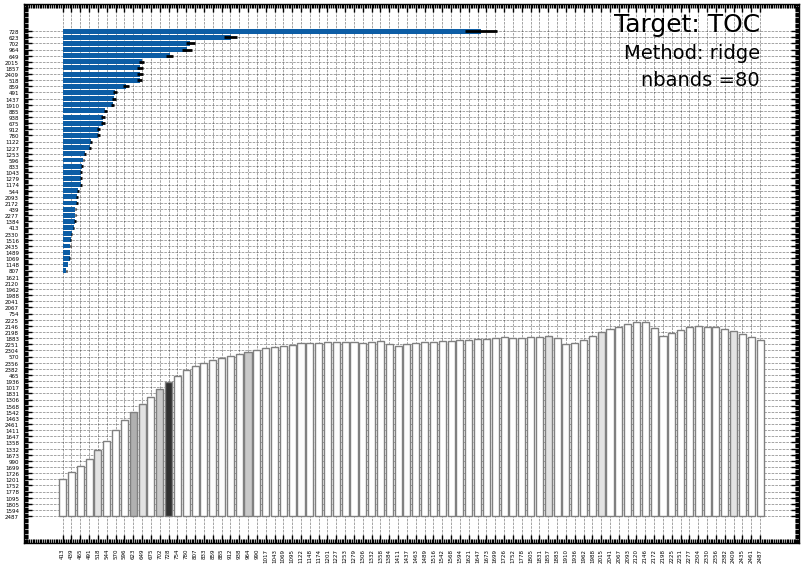

In [18]:
model_details['TOC'] = {'method': 'ridge', 'spec': sampled_spec[80], 'spec_proc': 'fod_log', 'n_bands': 80}
show_important_features_for ('TOC', model_details, feature_scores, 2, 70, 2)

In [23]:
# with open ('Feature.pickle', 'wb') as file:
#     pickle.dump(feature_scores, file)
     

In [24]:
# with open ('Models.pickle', 'wb') as file:
#     pickle.dump(model_details, file)

In [19]:
#Plotting Model Accuracy (ipywidgets)
def plot_model_acc (method, target, spec_preprocessing, n_bands):
    
    m = method
    t = target
    
    i = target_names.index(target)    
    
    p = spec_preprocessing
    n = n_bands
    tp = 'none'
    
    Y = HMtree[t][m][tp][p][n]
    
    y_test = Y['y_test']
    y_pred = Y['y_testP']
    L1y_pred = Y['L1y_testP']
    L1y_test = Y['L1y_test']

    y_train = Y['y_train']
    yhat_pred = Y['y_trainP']
    

    
    if m == 'plsr':
        y_pred = y_pred[:,0]
        #L1y_pred = L1y_pred[:,0]

    
    #iqrp_test = Y['iqrp_test']
    r2_test = Y['r2_test']
    #rpd_test = Y['rpd_test']

    #iqrp_train = find_iqrp(yhat_pred, y_train)
    r2_train = Y['r2_train']
    #rpd_train = find_rpd(yhat_pred, y_train)
    
    L1iqrp_test = Y['L1iqrp_test']
    L1r2_test = Y['L1r2_test']
    L1rpd_test = Y['L1rpd_test']
    
    y_tp = pd.DataFrame({'actual':y_test.values, 'predic': y_pred})
    z = np.polyfit(y_test, y_pred, 1)

    yhat_tp = pd.DataFrame({'actual':y_train.values, 'predic': yhat_pred})
    zhat = np.polyfit(y_train, yhat_pred, 1)
    
    L1y_tp = pd.DataFrame({'actual':L1y_test.values, 'predic': L1y_pred})
    L1z = np.polyfit(L1y_test, L1y_pred, 1)
    
    fig, axes = plt.subplots(2,2, figsize=(18,16))
    
    #with plt.style.context(('ggplot')): ---- PLOT of test-prediction --------------------------------------
    y_tp.plot.scatter(ax= axes[0][0], x="actual", y="predic", alpha=0.8, color = clr[i], edgecolors='k')
    axes[0][0].plot(y_test, np.polyval(z, y_test),  c='blue', linewidth=1)
    axes[0][0].plot(y_test, y_test, color='green', linewidth=1)
    axes[0][0].tick_params(axis='both', labelsize=10)
    axes[0][0].text(0.05, 0.95, target_names[i]+' (Test Score)', transform=axes[0][0].transAxes, fontsize = 20, color = clr[i])
    #axes[0][0].text(0.05, 0.90, 'IQRP ={:.2f}'.format(iqrp_test), transform=axes[0][0].transAxes, fontsize = 16)
    #axes[0][0].text(0.05, 0.85, 'RPD ={:.2f}'.format(rpd_test), transform=axes[0][0].transAxes, fontsize = 16)
    axes[0][0].text(0.05, 0.80, 'R2 ={:.2f}'.format(np.round(r2_test,3)), transform=axes[0][0].transAxes, fontsize = 16)
    axes[0][0].text(0.95, 0.15, 'Method: '+method, transform=axes[0][0].transAxes, 
                    horizontalalignment='right', fontsize = 20)
    
    L1y_tp.plot.scatter(ax= axes[0][1], x="actual", y="predic", alpha=0.8, color = clr[i], edgecolors='k')
    axes[0][1].plot(L1y_test, np.polyval(L1z, L1y_test),  c='blue', linewidth=1)
    axes[0][1].plot(L1y_test, L1y_test, color='green', linewidth=1)
    axes[0][1].tick_params(axis='both', labelsize=10)
    axes[0][1].text(0.05, 0.95, target_names[i]+' (L1-out Score)', transform=axes[0][1].transAxes, fontsize = 20, color = clr[i])
    axes[0][1].text(0.05, 0.90, 'IQRP ={:.2f}'.format(L1iqrp_test), transform=axes[0][1].transAxes, fontsize = 16)
    axes[0][1].text(0.05, 0.85, 'RPD ={:.2f}'.format(L1rpd_test), transform=axes[0][1].transAxes, fontsize = 16)
    axes[0][1].text(0.05, 0.80, 'R2 ={:.2f}'.format(np.round(L1r2_test,3)), transform=axes[0][1].transAxes, fontsize = 16)
    axes[0][1].text(0.95, 0.15, 'Method: '+method, transform=axes[0][1].transAxes, 
                    horizontalalignment='right', fontsize = 20)

    
     #------------------------ Ploting R2 Vs N_bands-----------------------------------
    
    #--- data for creating n_bands vs r2 scores plot -------------------------------
    
    pY = HMtree[t][m]['none'][p]        
    X = nbands_sampling
    
    Yr2 = []
    L1Yr2 = []
    
    for j in X:
        Yr2.append(pY[j]['r2_test'])
        L1Yr2.append(pY[j]['L1r2_test'])  
   
    j = 0
    while j < len(Yr2): 
        if Yr2[j] <= 0:
            Yr2[j] = 0
        if L1Yr2[j] <= 0:
            L1Yr2[j] = 0
        j = j + 1
 
    #------------------------------ STEM PLOT ---- for accuracy Vs n_bands ---------------------------------- 
    
    #with plt.style.context(('ggplot')): ---- PLOT of test-prediction --------------------------------------
    yhat_tp.plot.scatter(ax= axes[1][0], x="actual", y="predic", alpha=0.8, color = clr[i], edgecolors='k')
    axes[1][0].plot(y_train, np.polyval(zhat, y_train),  c='blue', linewidth=1)
    axes[1][0].plot(y_train, y_train, color='green', linewidth=1)
    axes[1][0].tick_params(axis='both', labelsize=10)
    axes[1][0].text(0.05, 0.95, target_names[i]+' (Train Score)', transform=axes[1][0].transAxes, fontsize = 20, color = clr[i])
    #axes[1][0].text(0.05, 0.90, 'IQRP ={:.2f}'.format(iqrp_train), transform=axes[1][0].transAxes, fontsize = 16)
    #axes[1][0].text(0.05, 0.85, 'RPD ={:.2f}'.format(rpd_train), transform=axes[1][0].transAxes, fontsize = 16)
    axes[1][0].text(0.05, 0.80, 'R2 ={:.2f}'.format(np.round(r2_train,3)), transform=axes[1][0].transAxes, fontsize = 16)
    axes[1][0].text(0.95, 0.15, 'Method: '+method, transform=axes[1][0].transAxes, 
                    horizontalalignment='right', fontsize = 20)
    
    
    axes[1][1].stem(X,L1Yr2)
    axes[1][1].tick_params(axis='both', labelsize=10)
    axes[1][1].text(0.00, 1.01,  target_names[i], transform=axes[1][1].transAxes,fontsize = 20, color = clr[i])
    axes[1][1].text(0.99, 1.01, 'Spec_prep: '+ p, transform=axes[1][1].transAxes, horizontalalignment='right', fontsize = 16)
    axes[1][1].text(0.17, 1.01, '(L1-out)', transform=axes[1][1].transAxes, horizontalalignment='left', fontsize = 16)
    axes[1][1].text(0.60, -0.1, 'n_bands', transform=axes[1][1].transAxes, horizontalalignment='right', fontsize = 16)
    axes[1][1].text(-0.1, 0.5, 'R2 Scores', horizontalalignment='left', verticalalignment='center', \
                rotation='vertical', transform=axes[1][1].transAxes, fontsize = 16)
        
   
    return    

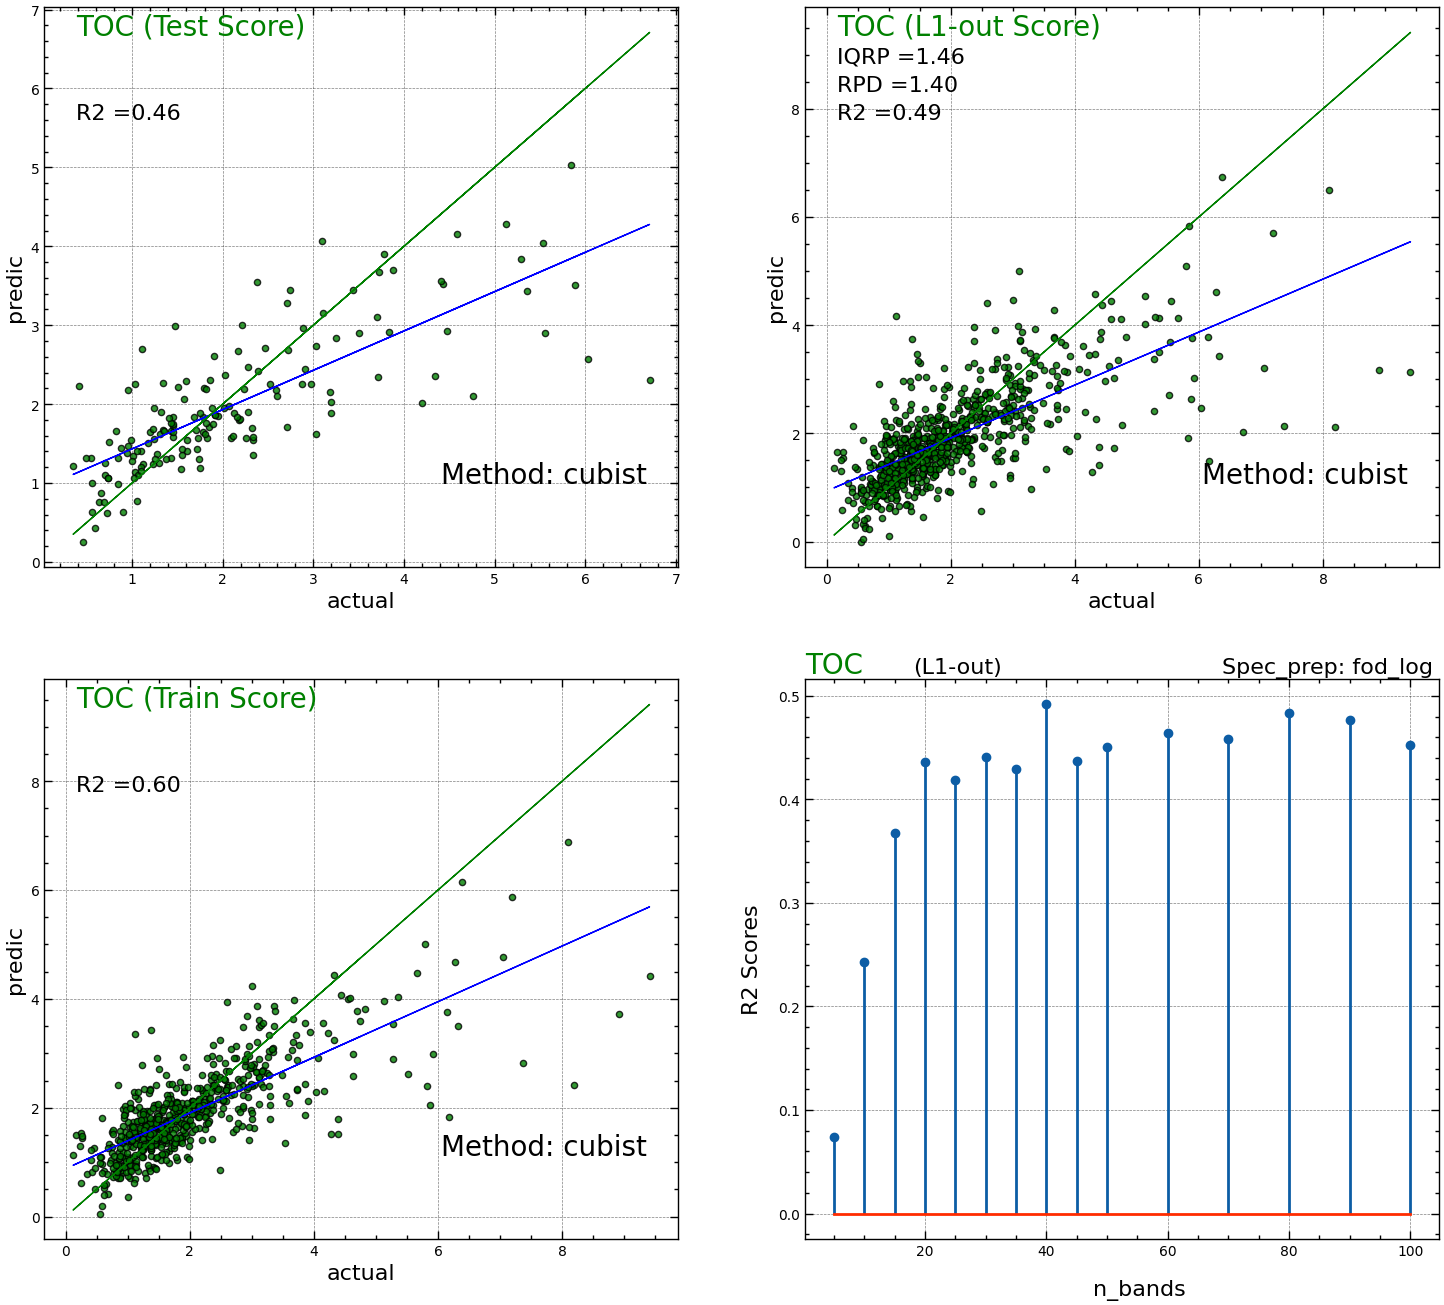

In [20]:
plot_model_acc ('cubist', 'TOC', 'fod_log', 40)